# Integrasi Numerik


Mengintegralkan suatu fungsi memiliki arti menghitung luas yang dibawah kurva yang didefinisikan oleh sebuah fungsi $f(x)$. Integral dituliskan dalam ekspresi matematika sebagai berikut,
$$I(a,b)=\int_a^b f(x)dx$$
Ini adalah integral tertentu, dan $I$ bermakna luas dari daerah di bawah kurva $f(x)$ mulai dari $x=a$ hingga $x=b$. Hasil dari integral seperti ini adalah bilangan. Fungsi $f(x)$ disebut dengan integrand, sedangkan $dx$ adalah variabel integrasi, yang menunjukan besar perpindahan dalam arah $x$ yang sangat kecil (infinitesimal). Secara simbolik integral dapat dikerjakan dengan mengetahui bentuk kebalikan dari turunan sebuah fungsi,
$$\int f(x)dx = F(x) + C$$
dengan $F(x)$ merupakan fungsi integral dari $f(x)$. Persamaan seperti ini disebut dengan integral tak tentu. Variabel $C$ adalah konstanta integrasi yang selalu ada di setiap pengerjaan integral. Fungsi-fungsi integral dapat dilihat dari tabel integral, yang sebagian besar fungsi memiliki aturan yang pasti.

Sama dengan diferensiasi, dengan metode numerik integrasi dilakukan tanpa harus mengetahui bentuk fungsi integralnya. Melalui diskritisasi fungsi $f(x)$, integral dikembalikan ke konsep fundamentalnya, yaitu jumlah dari elemen luas di dalam batas yang ditentukan. Dapat dituliskan,
$$
I=\sum_{i=0}^n A_if(x_i)
$$
Dalam persamaan ini $A_i$ dikenal dengan kuadratur yang digunakan untuk memberikan elemen luas pada segmen data ke-$i$. Kuadratur yang paling sederhana adalah 
$$A_i=\Delta x=x_{i+1}-x_i$$
yaitu jarak antara titik-titik data yang diintegralkan. Untuk deretan data yang memiliki jede $x$ merata, sebagai berikut,
$$
\begin{array}{c|cccc}
x_i & x_1 & x_2 & ... & x_n \\
\hline
f(x_i) & y_1 & y_2 & ... & y_n
\end{array}
$$
integral dapat dihitung secara sederhana dengan, $$I=\Delta x \sum_{i=1}^n y_i$$
Namun perlu diingat bahwa cara ini tidak akurat.

## Metode trapesium

Elemen area $L_i$ dibawah kurva $f(x)$ dapat dihitung menggunakan persamaan berikut,
$$L_i = \frac{y_i+y_{i+1}}{2}\Delta x$$
Metode perhitungan luas seperti ini lebih mendekati luas sebenarnya dengan jalan mengambil interpolasi garis dari titik data $(x_i,y_i)$ ke $(x_{i+1}, y_{i+1})$. Elemen luas merupakan luas trapesium dibatasi oleh $x_i$ dan $x_{i+1}$. Untuk keseluruhan batas integrasi,
$$
\int_a^b f(x)dx \approx \frac{\Delta x}{2} \left[ y_1 + 2y_2 + 2y_3 + ... + 2y_{n-1} + y_n \right]
$$
Perhatikan bahwa indeks penjumlahan dimulai dari $1$, namun dalam program menggunakan Python indeks dimulai dari $0$.

In [2]:
# pustaka yang diperlukan
import numpy as np
import matplotlib.pyplot as plt

Pada contoh berikut, kita melakukan integral numerik untuk fungsi,
$$f(x)=2x + 3\sin(\frac{\pi}{3}x) + 2$$
dengan batas $0<x<10$.
Secara analitik dapat dikerjakan sebagai berikut,
$$
\int_0^{10} f(x) = \left. x^2 - \frac{9}{\pi} \cos(\frac{\pi}{3}x) + 2x \right|_0^{10}
$$


solusi analitik: 121.432394
integral numerik: 113.420959


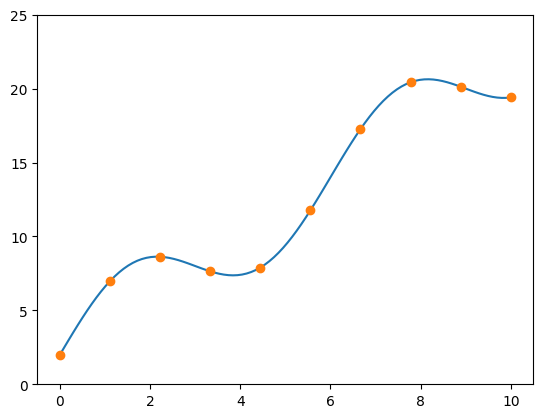

In [13]:
# integrasi metode trapesium
# data memiliki jeda merata pada sumbu x

def trapes(y,dx):
    iy=y[0]+y[-1]
    for i in range(len(x)-1):
        iy+=2*y[i]
    return dx*iy/2

fun=lambda x: 2*x + 3*np.sin(np.pi*x/3) + 2
dfun=lambda x: x**2 - 9*np.cos(np.pi*x/3)/np.pi + 2*x

xr = np.linspace(0,10,100)
yr = fun(xr)
x = np.linspace(0,10,10) # sampling
y = fun(x)

iy = trapes(y,1)
ir = dfun(10)
print(f'solusi analitik: {ir:0.6f}')
print(f'integral numerik: {iy:0.6f}')

plt.ylim(0,25)
plt.plot(xr,yr)
plt.plot(x,y,'o')
plt.show()

Terdapat simpangan antara hasil perhitungan numerik, $I_N$, dengan perhitungan teoretik, $I_{th}$. Pada perhitungan diatas perbedaan dihitung dengan akar kuadrat adalah,
$$
\epsilon = \sqrt{(I_N - I_{th})^2} = 1.215
$$

Hal ini tidak dapat dihindari, akan tetapi dapat diperkecil melalui penambahan resolusi data sehingga memperkecil $\Delta x$, atau dengan menggunakan metode integrasi yang diperbaiki. Sekarang kita amati bagaimana $\epsilon$ bergantung pada jumlah data dalam metode trapesium.

integral=113.420959; epsilon=8.011436
integral=117.155271; epsilon=4.277123
integral=118.978455; epsilon=2.453939
integral=120.775374; epsilon=0.657020
integral=121.664551; epsilon=0.232156
integral=122.195199; epsilon=0.762805
integral=122.547798; epsilon=1.115404
integral=122.799090; epsilon=1.366696
integral=122.987253; epsilon=1.554859
integral=123.133422; epsilon=1.701028
integral=123.250244; epsilon=1.817850


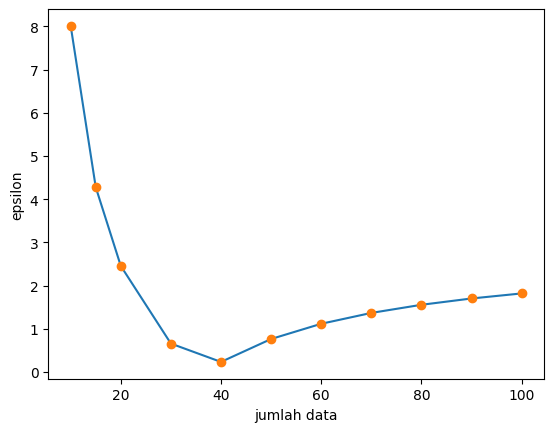

In [24]:
eps=[]
nd=[10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for n in nd:
    x = np.linspace(0,10,n) # sampling
    y = fun(x)
    dx=10/n
    iy = trapes(y,dx)
    er=np.sqrt((iy-ir)**2)
    print(f'integral={iy:0.6f}; epsilon={er:0.6f}')
    eps.append(er)

plt.plot(nd,eps,'-')
plt.plot(nd,eps,'o')
plt.xlabel('jumlah data')
plt.ylabel('epsilon')
plt.show()
    

## Formula Newton-Cotes

Dalam metode trapesium nilai integran diambil dari rata-rata dua titik yang berurutan dalam data. Ini sama dengan mengambil interpolasi garis ($n=1$) untuk menentukan nilai $f(x)$ di tengah-tengah segmen.
Pada dasarnya formula Newton-Cotes menggunakan interpolasi polinomial orde-$n$ pada titik-titik antara data untuk mendapatkan fungsi yang mendekati kurva sesungguhnya. Sehingga untuk data dengan jeda absis $x_0, x_1, ... , x_n$, perhitungan menghitung elemen luas menggunakan pendekatan polinomial Lagrange sebagai berikut,
$$
P_n(x) = \sum_{i=0}^n f(x_i) \prod_{j=0,j\neq i}^n \frac{x-x_j}{x_i-x_j}
$$

Dengan menuliskan fungsi kardinal $\ell_i$,
$$
\ell_i = \prod_{j=0,j\neq i}^n \frac{x-x_j}{x_i-x_j}
$$
kuadratur untuk metode integrasi Newton-Cotes adalah,
$$
A_i = \int_a^b \ell_i(x) dx;~~~ i=0, 1, 2, ..., n
$$

Dengan demikian integral dihitung secara numerik dengan,
$$
I=\sum_{i=0}^n A_iy_i
$$

Dalam prakteknya $n$ tidak diambil terlalu besar, hanya $n=1,2,3$ yang biasa digunakan, yang diberi nama,

1. $n=1$, metode trapesium, dengan perhitungan integral
   $$I=[y_i+y_{i+1}]\frac{h}{2}$$
2. $n=2$, aturan simpson 1/3, dengan perhitungan integral
   $$I=\left[y_{i} + 4 y_{i+1} + y_{i+2}\right] \frac{h}{3}; ~~~ i=0, 3, 6, ... $$
3. $n=3$, aturan simpson 3/8, dengan perhitungan integral $$I=[y_i + 3y_{i+1}+3y_{i+2}+y_{i+3}]\frac{3h}{8}; ~~~ i=0, 4, 8, ...$$

Perhatikan jumlah data yang diperlukan untuk setiap metode. Pada data-data yang tak tentu jumlahnya metode trapesium adalah yang paling mudah untuk digunakan.

# Integral dari data dengan jeda tak seragam

Data diskrit misalnya data hasil pengukuran dengan periode sampling tertentu dapat secara langsung dihitung nilai integralnya menggunakan metode-metode diatas. Terdapat beberapa teknik untuk melakukan integrasi numerik dengan jeda absis data yang tidak seragam. Metode yang didisain khusus adalam menggunakan kuadratur Gauss, namun perlu fungsi yang berperilaku baik. Metode gaus kuadratur memberikan hasil yang akurat dengan metode pembobotan pada segmen data tertentu, biasanya diambil sebanyak lima data per segmen. Integral yang dilakukan menggunakan aturan sebagai berikut,
$$
\int_a^b W(x)f(x)dx = \sum_{i=1}^n w_if(x_i)
$$
dengan $n$ adalah jumlah data. Ketika melakukan integrasi dalam satu segmen, batas integrasi ditransformasi menjadi $a\leftarrow -1$ dan $b\leftarrow 1$. Dan variabel $x$ diubah secara bersesuaian. Kebaikan dari kuadratur Gauss adalah kemungkinan untuk memberikan bobot yang berbeda pada segmen-segmen tertentu yang sensitif terhadap perubahan, seperti yang ditemui pada fungsi-fungsi transenden.

Metode yang cukup efektif untuk melakukan integral pada data dengan spasi-$x$ yang sembarang adalah dengan menggunakan interpolasi, baik polinomial ataupun spline, bahkan dapat digunakan pula extrapolasi misalnya untuk data pengukuran yang mengandung derau. Setelah itu dilakukan sampling ulang terhadap fungsi interpolasi dengan jeda seragam. Nilai integral didapat dengan mudah dihitung dengan metode-metode Newton-Cotes. Untuk interpolasi polinomial dengan jumlah data $n+1$, dapat dituliskan,
$$
\int_a^b P(x)dx \approx \sum_{i=1}^{n_s} P_n(x_i)(x_{i+1}-x_i) 
$$
Dalam persamaan ini $n$ adalah orde dari polinomial, dan $n_s$ adalah jumlah data baru setelah sampling ulang.

## Integral garis

Berbeda dengan integral biasa, integral garis dilakukan untuk menghitung panjang lintasan pada ruang yang dipengaruhi fungsi tertentu. Jadi bukan luas dibawah kurva yang dihitung, melainkan panjang dari kurva. Jika $C$ menunjukkan kurva dari sebuah lintasan dengan elemen panjang $dl$, maka,
$$L=\int_C dl$$
adalah pangjang total dari kurva $C$. Secara diskrit untuk kasus 2 dimensi, dengan perpindahan $\Delta x_i=x_{i+1}-x_i$ dan $\Delta y_i = y_{i+1}-y_i$ 
$$
L = \int_C dl ~~~\approx \sum_{i=1}^{n-1} \sqrt{(\Delta x_i)^2 + (\Delta y_i)^2} 
$$



In [3]:
fun=lambda x: 2*x + 3*np.sin(np.pi*x/3) + 2

x=np.linspace(0,10, 50)
y=fun(x)
L=0

# menghitung panjang lintasan kurva
for i in range(len(x)-1):
    dx=x[i+1]-x[i]
    dy=y[i+1]-y[i]
    dl=np.sqrt(dx**2+dy**2)
    L+=dl

print(f'panjang lintasan: {L:0.6}')

panjang lintasan: 25.9219


Dalam integral garis variabel integral dapat berupa skalar atau vektor. Jika digunakan variabel vektor,
$$\oint_C d\vec l = 0$$

Berbeda dengan perhitungan vektor, integral garis skalar pada lintasan tertutup tidak bernilai nol dan selalu bernilai positif. Ekspresi matematika untuk integral lintasan tertutup ditulis sebagai,
$$\oint_C dl\neq 0$$

Dalam banyak kasus fisika integral garis digunakan untuk mencari pengaruh dari sebuah fungsi, dikenal dengan medan, terhadap suatu besaran pada lintasan tertentu. Kasus-kasus seperti ini dituliskan sebagai berikut,
$$
I_l=\oint_C \vec f(x,y)\cdot d\vec l
$$
Jika $I_l=0$, medan $\vec f(x,y)$ disebut medan konservatif.

## Integral lipat multi-dimensi

Elemen dari variabel integral $dx$ merupakan garis. Variabel ini digunakan dalam kasus satu dimensi. Pada kasus dua dimensi digunakan elemen luas $ds=dx~dy$, dan pada tiga dimensi digunakan elemen volume $dv=dx~dy~dz$. Perhatikan integral-integral berikut,
$$\iint ds = S$$
yaitu keseluruhan domain permukaan integral dan,
$$\iiint dv = V$$
adalah sekeluruhan domain volume integral.

Integral yang menggunakan variabel diferensial $ds$ adalah integral permukaan yang memiliki dimensi-2, sedangkan $dv$ adalah integral volume yang memiliki dimensi-3. Hanya integral permukaan yang memiliki bentuk vektor. Arah vektor permukaan merupakan vektor normal dari permukaan berarah keluar. Perhatikan bahwa, arah luar dan dalam bersifat perjajian dan dapat ditentukan sesuai kasus yang dihadapi akan tetapi harus konsisten.

Integran dari persamaan-persamaan diatas adalah fungsi, dengan dimensi bersesuaian, yang bekerja pada tiap elemen. Sehingga fungsi integran merupakan fungsi yang bergantung pada ruang. Bentuk integral lipat dikerjakan secara numerik satu persatu, sebagai berikut,
$$
\begin{aligned}
\iint f(x,y) ds &= 
\int_{y_0}^{y_1}
\left[\int_{x_0}^{x_1} f(x,y)dx\right]dy &\rightarrow 2D \\
&&\\
\iiint f(x,y,z) dv &= 
\int_{z_0}^{z_1}
\left[
\int_{y_0}^{y_1}
\left[\int_{x_0}^{x_1} f(x,y,z)dx\right]dy\right]dz &\rightarrow 3D
\end{aligned}
$$

Dalam ekspresi-ekspresi diatas $x$, $y$, dan $z$ adalah variabel-variabel bebas.
Sebagai contoh untuk kasus 2-dimensi, diberikan data matriks sebagai berikut,
$$
\begin{array}{l|ccccc}
y_i\backslash x_i & x_1 & x_2 & x_3 & ... & x_m\\
\hline
y_1 & f_{x_1, y_1} &  f_{x_2, y_1} &  f_{x_3, y_1} & ... &  f_{x_m, y_1}\\
y_2 & f_{x_1, y_2} &  f_{x_2, y_2} &  f_{x_3, y_2} & ... &  f_{x_m, y_2}\\
\vdots & \vdots & \vdots & \vdots &  & \vdots\\
y_n & f_{x_1, y_n} &  f_{x_2, y_n} &  f_{x_3, y_n} & ... &  f_{x_m, y_n}\\\end{array}
$$
dalam fungsi integran, $x$ dan $y$ merepresentasikan indeks dari elemen matriks. Menggunakan skala yang cocok untuk $x_i$ dan $y_j$ dapat diganti dengan indeks integer $i$ dan $j$. Untuk kasus 3-dimensi data disusun berupa tensor.

Integral diselesaikan sebagai berikut,
$$
I = \sum_j^n A_j \sum_i^m A_i f_{i,j}
$$
dengan $A_i$ dan $A_j$ kuadratur yang digunakan dalam integrasi numerik, berturut-turut untuk sumbu-$x$ dan sumbu-$y$.